# clip_grad_norm_ 
- <font color='red'>是深度学习中防止梯度爆炸的核心手段之一</font>

下面做一个系统性的梳理。

## 梯度爆炸的本质
<font color='red'>在反向传播过程中，梯度通过链式法则逐层相乘</font>。
- 如果这些乘积项大于 1.0，梯度会像滚雪球一样指数级增长，导致权重更新幅度过大，模型无法收敛，甚至 loss 变成 NaN。



## clip_grad_norm_ 的工作原理
它对所有参数的梯度作为一个整体向量计算 L2 范数，如果超过设定的阈值 max_norm，就按比例等比缩小所有梯度：

In [1]:
from IPython.display import Image

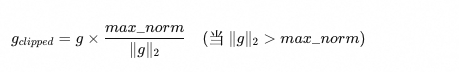

In [2]:
Image(filename='./Image/clip_grad_norm_.png')

例如梯度范数为 2.5、max_norm=1.0 时，所有梯度会乘以 1.0 / 2.5 的<font color='red'>缩放因子</font>

## 使用方式
关键位置：<font color='red'>loss.backward() 之后、optimizer.step() 之前</font>

In [ ]:
optimizer.zero_grad()
loss = criterion(outputs, labels)
loss.backward()

# 梯度裁剪
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

optimizer.step()

常见参数：
- max_norm：梯度范数的上限阈值，常用值为 1.0 或 0.5
- norm_type：范数类型，默认 2.0（L2 范数）

## 与 clip_grad_value_ 的区别

| | clip_grad_norm_ | clip_grad_value_ |
|---|---|---|
| 裁剪对象 | 所有梯度组成的整体向量 | 每个梯度分量单独截断 |
| 效果 | 保持梯度方向不变，等比缩放 | 硬性截断到 [-clip_value, +clip_value] |
| 适用场景 | 通用，最常用 | <font color='red'>个别参数梯度异常偏大时</font> |



## 典型应用场景
- RNN / LSTM：<font color='red'>由于时间步的递归展开，梯度爆炸最为常见</font>
- 大语言模型（LLM）训练：<font color='blue'>超长序列导致梯度累积放大</font>
- GAN 训练：对抗训练本身不稳定，裁剪可提升收敛性
- 深层 CNN：网络极深时辅助稳定训练

## 注意事项
- max_norm 设太小会导致梯度过度缩放、训练停滞；设太大则裁剪无效，需通过实验调优
- <font color='blue'>注意传入的是 model.parameters() 而非 model 本身，这是常见错误</font>
- 梯度裁剪作用于梯度，与 L1/L2 正则化（作用于权重本身）目的不同

# Loss 变 NaN 排查清单

## 一句话总结
- Inf 是浮点数系统中"数值太大装不下"的标记。它本身有确定的运算规则，
  - <font color='red'>但一旦 Inf 参与 Inf - Inf、Inf / Inf、0 × Inf 这类"无穷对无穷"的运算，就会退化为 NaN</font>
  - <font color='blue'>这也是训练中 loss 从 Inf 变成 NaN 的根本原因</font>。
  
  
当训练过程中 loss 突然变成 NaN 或 Inf，按以下顺序逐步排查：

## 第一步：确认 NaN 出现的位置
在训练循环中加入检测代码，精确定位是哪一步出了问题：

In [ ]:
loss = criterion(outputs, labels)

if torch.isnan(loss) or torch.isinf(loss):
    print(f"NaN detected at epoch {epoch}, step {step}")
    print(f"Loss value: {loss}")
    print(f"Max output: {outputs.max()}, Min output: {outputs.min()}")
    
    # 保存当前 batch 数据用于复现
    torch.save(inputs, 'nan_inputs.pt')
    torch.save(labels, 'nan_labels.pt')
    break

loss.backward()

## 第二步：检查梯度状态
<font color='red'>在 backward() 之后、step() 之前打印梯度信息：</font>

In [ ]:
loss.backward()

for name, param in model.named_parameters():
    if param.grad is not None:
        
        grad_norm = param.grad.norm().item()
        
        if torch.isnan(param.grad).any() or torch.isinf(param.grad).any():
            print(f"️ NaN/Inf gradient in: {name}, norm: {grad_norm}")
        if grad_norm > 100:
            print(f" Gradient explosion in: {name}, norm: {grad_norm}")

## 第三步：逐项排查常见原因

### ① 学习率过大
  - 表现：loss 先正常下降，<font color='red'>突然跳到一个极大值后变 NaN</font>
  - 解决：降低学习率（如从 1e-3 降到 1e-4），或使用学习率预热（warmup）
  
### ② 梯度爆炸
  - 表现：梯度范数持续增长，某一层梯度远大于其他层
  - 解决：加入 clip_grad_norm_，从 max_norm=1.0 开始尝试
  
### ③ 数值溢出
  - 表现：<font color='red'>exp() 或 log() 的输入值过大/过小</font>
  - 常见位置：
    - Softmax 前未做数值稳定处理（<font color='red'>PyTorch 的 CrossEntropyLoss 内部已处理，但自定义 loss 需注意</font>）
    - log(0) → 使用 torch.clamp(x, min=1e-8) 或 torch.log(x + 1e-8)
    - exp(x) 中 x 过大 → 使用 torch.clamp(x, max=80)
    
### ④ 数据问题
  - 表现：<font color='red'>特定 batch 触发 NaN，换 batch 后正常</font>
  - 排查：
    - 检查输入数据是否包含 NaN 或 Inf：torch.isnan(inputs).any()
    - 检查 label 是否合法（如分类任务中 label 超出类别范围）
    - 检查数据预处理是否引入了异常值（如除零、归一化错误）
    
### ⑤ 模型结构问题
  - 表现：训练一开始就 NaN，或某一层输出异常
  - 排查：
    - 逐层打印中间输出，定位哪一层开始产生 NaN
    - 检查是否有除以零的操作
    - 检查 BatchNorm 的 batch size 是否太小（建议 ≥ 8）
    
### ⑥ 混合精度训练（AMP）相关
  - 表现：FP16 下容易出现溢出
  - 解决：
    - 确认使用了 GradScaler
    - 检查是否手动将某些操作强制转为 FP16（应保持 FP32）
    - <font color='red'>尝试关闭 AMP 看是否仍复现</font>


## 第四步：快速验证修复效果
修复后建议做以下验证：

In [ ]:
# 训练循环中加入监控
grad_norms = []

for step, (inputs, labels) in enumerate(dataloader):
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()

    # 记录梯度范数
    total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    grad_norms.append(total_norm.item())

    optimizer.step()
    optimizer.zero_grad()

    # 每 100 步打印一次
    if step % 100 == 0:
        print(f"Step {step} | Loss: {loss.item():.4f} | Grad Norm: {total_norm:.4f}")

### 正常状态参考：
- 梯度范数在 0.1 ~ 10 之间波动
- Loss 平稳下降，<font color='red'>无突然跳变</font>
- 无 NaN / Inf 输出

## 速查总结

| 现象 | 最可能原因 | 首选方案 |
|---|---|---|
| loss 突然跳到极大值后 NaN | 学习率过大 | 降低 lr / 加 warmup |
| 梯度范数持续增长 | 梯度爆炸 | `clip_grad_norm_` |
| 特定 batch 才 NaN | 数据异常 | 检查该 batch 数据 |
| 训练一开始就 NaN | 模型/数据预处理问题 | 逐层排查输出 |
| FP16 训练时 NaN | 混合精度溢出 | 检查 GradScaler |

